In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)

c:\Users\Daniel\venv-optimizer\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configurable Monte Carlo price sampler

Every decision variable from the decision grid is exposed as a variable in the **Configuration** cell below.
Change a value there and re-run the notebook to produce a different sampled set.

Pipeline: **configure → load data & build deck → generate samples → visualise**.

If `curve_columns` has length 1 the sampler runs in **single-curve mode**, where variables 9
(`curve_switch_level`) and 10 (`curve_weights`) have no effect.

## Decision grid

Each knob below maps to one variable in the Configuration cell. **Bold** options are the defaults.

| # | Knob | Variable | Options | What it produces |
|---|---|---|---|---|
| 1 | **Atomic card** — the block of time copied intact; everything inside is preserved, everything above is reshuffled | `card_level` | interval | Destroys intraday shape; noise |
| | | | **day** | Keeps daily peak/off-peak shape |
| | | | week | Keeps weekday rhythm too |
| | | | month | Keeps full within-month dynamics |
| | | | year | Whole real year reused; least variety |
| 2 | **Day order within month** — real consecutive sequence vs shuffled | `day_order` | consecutive | Day-to-day autocorrelation kept |
| | | | **shuffled** | Day-to-day correlation broken |
| 3 | **Day draw** — can a real day be picked more than once | `day_draw` | without_replacement | Each real day used ≤ once |
| | | | **with_replacement** | Days may repeat / be skipped |
| 4 | **Month calendar position** — true seasonal slot vs anywhere | `month_position` | free | Seasonality destroyed |
| | | | **pinned** | Seasonality preserved |
| 5 | **Month ↔ source-year coupling** — one real year for all 12 months vs each its own | `month_source_year` | shared | Cross-month coherence within a year kept |
| | | | **independent** | Each month borrows a different year |
| 6 | **Year trend alignment** — source year tracks target year so the long-term rise survives | `trend_alignment` | aligned | Rising price escalation preserved |
| | | | **flat** | Long-term trend destroyed |
| 7 | **Weekday identity** — respect weekday/weekend structure | `weekday_identity` | pinned | Weekday/weekend pattern kept |
| | | | **off** | Weekday pattern ignored |
| 8 | **Count integrity** — month lengths from the real target calendar vs the borrowed source year | `count_integrity` | target | Dates never drift |
| | | | **source** | Feb 28/29 can mismatch target |
| 9 | **Curve-switch level** *(multi-curve only)* — how often the drawn scenario changes identity; sets the spread and shape | `curve_switch_level` | day | Collapse to mean, narrowest |
| | | | month | Narrows via averaging over 12 picks |
| | | | **year** | Full envelope, multimodal (~5 modes) |
| | | | path | Widest, ~5 discrete levels |
| 10 | **Curve weights** *(multi-curve only)* — probability assigned to each curve | `curve_weights` | **equal** | Every scenario equally probable |
| | | | list of floats | Up-weighted curves get taller peaks; pulls P50 toward them |
| 11 | **Distribution aggregation level** *(chart only)* — what each sample is collapsed to before the density is built | `aggregation_level` | interval | Full spread incl. intraday spikes; very wide |
| | | | daily / monthly | Medium smoothing |
| | | | **yearly** | Smooth, one point per year per sample |

> Knobs 9–10 only apply when sampling across multiple curves. With a single curve (`len(curve_columns) == 1`) there is nothing to switch between, so they have no effect.

## Configuration — the variable editor

Each variable below is one decision variable from the grid. Allowed values are listed in the comment beside it;
the value currently set is the one that will be used.

In [2]:
# DATA SOURCE
timeseries_path = "2_Processed_data/future_prices.csv"   # CSV with a 'Date' column + one column per curve
curve_columns = [                                        # which column(s) to sample from
    "NSW - Aurora central",
    "NSW - Aurora low",
    "NSW - Aurora messy",
    "NSW - Aurora Gov intervention",
    "NSW - Aurora net zero",
]
focused_col = "NSW - EDP conservative"

# TIMELINE
granularity_minutes = 30
sample_start = "2027-01-01"
sample_end   = "2059-12-31 23:30"
n_samples    = 2000
random_seed  = 42
visual_title = "NSW Forward Electricity Price Distribution"

# Decision variables 1-8  (shape each individual path)
card_level        = "day"              # 1  "interval" | "day" | "week" | "month" | "year"
day_order         = "shuffled"         # 2  "shuffled" | "consecutive"
day_draw          = "with_replacement" # 3  "with_replacement" | "without_replacement"
month_position    = "pinned"           # 4  "pinned" | "free"
month_source_year = "independent"      # 5  "independent" | "shared"
trend_alignment   = "aligned"             # 6  "flat" | "aligned"
weekday_identity  = "off"              # 7  "off" | "pinned"
count_integrity   = "target"           # 8  "source" | "target"

# Decision variables 9-10  (multi-curve only: shape the distribution)
curve_switch_level = "path"            # 9   "day" | "month" | "year" | "path"
curve_weights      = "equal"           # 10  "equal"  OR  a list of floats, one per curve_columns entry


# Decision variable 11  (visual only: how the distribution is aggregated for the plot)
aggregation_level = "yearly"           # 11  "interval" | "daily" | "monthly" | "yearly"

## Load data and build the "deck of cards"

Read the timeseries, then group every complete day into a lookup keyed by
`(curve, year, month)`. Each day also remembers its weekday so decision variable 7 can use it.

In [3]:
single_curve_mode = len(curve_columns) == 1

if single_curve_mode:
    print("Single-curve mode: decision variable 9 (curve_switch_level) and 10 (curve_weights) are ignored.")
else:
    print(f"Multi-curve mode: {len(curve_columns)} curves | switch={curve_switch_level} | weights={curve_weights}")

Multi-curve mode: 5 curves | switch=path | weights=equal


Read and clean the timeseries

In [4]:
def load_data():
    raw_curves = pd.read_csv(timeseries_path)
    raw_curves["Date"] = pd.to_datetime(raw_curves["Date"])
    raw_curves["Year"] = raw_curves["Date"].dt.year
    raw_curves = raw_curves.sort_values("Date").reset_index(drop=True)
    for curve in curve_columns:
        raw_curves[curve] = pd.to_numeric(raw_curves[curve], errors="coerce").round(2)

    return raw_curves

raw_curves = load_data()

In [5]:
intervals_per_day = int(24 * 60 / granularity_minutes)

Target timeline we must reproduce for every sample

In [6]:
target_index = pd.date_range(sample_start, sample_end, freq=f"{granularity_minutes}min")
target_periods = len(target_index)
target_years = sorted(target_index.year.unique())

Deck of cards: every complete day, grouped by (curve, year, month), plus its weekday

In [7]:
def create_card_deck():
    day_pool = {}
    for (year, month), group in raw_curves.groupby([raw_curves["Date"].dt.year, raw_curves["Date"].dt.month]):
        for curve in curve_columns:
            days = []
            for _, day_group in group.groupby(group["Date"].dt.day):
                values = day_group[curve].to_numpy()
                if len(values) == intervals_per_day:                 # only keep full days
                    weekday = int(day_group["Date"].dt.dayofweek.iloc[0])
                    days.append((weekday, values))
            if days:
                day_pool[(curve, int(year), int(month))] = days

    # Only source from years that have all 12 months for every curve (drops partial start/end years).
    all_years = sorted({year for (_, year, _) in day_pool})
    available_years = [
        year for year in all_years
        if all((curve, year, month) in day_pool for curve in curve_columns for month in range(1, 13))
    ]
    print(f"Loaded {len(raw_curves)} rows | {intervals_per_day} intervals/day "
        f"| complete source years {available_years[0]}-{available_years[-1]} | target periods {target_periods}")

    return day_pool, available_years

day_pool, available_years = create_card_deck()

Loaded 591696 rows | 48 intervals/day | complete source years 2027-2059 | target periods 578544


## The sampler helpers

Small readable helpers, one per decision, then `generate_one_sample` stitches them together.
Written for clarity over speed: plain loops, one whole day copied at a time.

In [8]:
# --- decision variable 10: curve weights ---
if single_curve_mode or curve_weights == "equal":
    _weights = None                                  
else:
    _weights = np.array(curve_weights, dtype=float)
    _weights = _weights / _weights.sum()

random choice of curve

In [9]:
def pick_curve(rng):
    """Decision variable 10: choose a curve (uniform, or by custom weights)."""
    if single_curve_mode:
        return curve_columns[0]
    return str(rng.choice(curve_columns, p=_weights))

choice of year (random or aligned)

In [10]:
def pick_source_year(target_year, rng):
    """Decision variable 6: aligned keeps the target year (trend); flat picks a random year."""
    if trend_alignment == "aligned" and target_year in available_years:
        return target_year
    return int(rng.choice(available_years))

choice of days in month

In [11]:
def month_length(target_year, source_year, month):
    """Decision variable 8: how many days the month should have."""
    year = target_year if count_integrity == "target" else source_year
    return pd.Timestamp(year, month, 1).days_in_month

choice of days (weekdays vs weekends)

In [12]:
def target_weekdays(target_year, month, n_days):
    """Weekdays of the real target month (used by decision variable 7), cycled to n_days."""
    days = pd.Timestamp(target_year, month, 1).days_in_month
    weekdays = [pd.Timestamp(target_year, month, d).dayofweek for d in range(1, days + 1)]
    return (weekdays * (n_days // len(weekdays) + 1))[:n_days]

Final choice of curve -> source_year -> source_month

In [13]:
def days_for(curve, source_year, source_month):
    return day_pool[(curve, source_year, source_month)]

# The sampler

In [14]:
def build_month(curve, source_year, source_month, target_year, target_month, n_days, switch_per_day, rng):
    """Return one month of values, honouring decision variables 1, 2, 3, 7."""

    # Decision variable 1 = month: copy the whole source month intact.
    if card_level == "month":
        return np.concatenate([arr for _, arr in days_for(curve, source_year, source_month)])

    # Decision variable 1 = interval: destroy intraday shape by sampling loose values.
    if card_level == "interval":
        flat = np.concatenate([arr for _, arr in days_for(curve, source_year, source_month)])
        return rng.choice(flat, size=n_days * intervals_per_day, replace=True)

    # Decision variable 1 = week: tile the month with contiguous 7-day blocks.
    if card_level == "week":
        day_arrays = [arr for _, arr in days_for(curve, source_year, source_month)]
        windows = [day_arrays[i:i + 7] for i in range(max(1, len(day_arrays) - 6))]
        picked = []
        while len(picked) < n_days:
            picked.extend(windows[int(rng.integers(len(windows)))])
        return np.concatenate(picked[:n_days])

    # Decision variable 7: keep each target day's weekday.
    if weekday_identity == "pinned":
        picked = []
        for weekday in target_weekdays(target_year, target_month, n_days):
            day_curve = pick_curve(rng) if switch_per_day else curve
            days = days_for(day_curve, source_year, source_month)
            matches = [arr for w, arr in days if w == weekday] or [arr for _, arr in days]
            picked.append(matches[int(rng.integers(len(matches)))])
        return np.concatenate(picked)

    # Decision variable 2 = consecutive: keep a real run of days in order.
    if day_order == "consecutive":
        day_arrays = [arr for _, arr in days_for(curve, source_year, source_month)]
        start = int(rng.integers(len(day_arrays)))
        picked = [day_arrays[(start + i) % len(day_arrays)] for i in range(n_days)]
        return np.concatenate(picked)

    # Decision variable 2 = shuffled (with per-day curve switching if requested).
    if switch_per_day:
        picked = []
        for _ in range(n_days):
            day_arrays = [arr for _, arr in days_for(pick_curve(rng), source_year, source_month)]
            picked.append(day_arrays[int(rng.integers(len(day_arrays)))])
        return np.concatenate(picked)

    day_arrays = [arr for _, arr in days_for(curve, source_year, source_month)]
    replace = (day_draw == "with_replacement") or (n_days > len(day_arrays))   # Decision variable 3
    idx = rng.choice(len(day_arrays), size=n_days, replace=replace)
    return np.concatenate([day_arrays[i] for i in idx])


In [15]:
def build_year(curve, source_year):
    """Decision variable 1 = year: copy a whole source year intact."""
    parts = []
    for month in range(1, 13):
        key = (curve, source_year, month)
        if key in day_pool:
            parts.extend(arr for _, arr in day_pool[key])
    return np.concatenate(parts)

In [16]:
def generate_one_sample(rng):
    """Build one full path, honouring every decision variable."""

    switch_per_day = (not single_curve_mode) and curve_switch_level == "day"

    path_curve = pick_curve(rng) if (not single_curve_mode and curve_switch_level == "path") else None

    values = []
    year_i = 0

    while len(values) < target_periods:
        target_year = target_years[min(year_i, len(target_years) - 1)]
        year_i += 1

        # Decision variable 9: decide the curve for this 12-month cycle (if it switches per year/path).

        if single_curve_mode:
            year_curve = curve_columns[0]
        elif curve_switch_level == "path":
            year_curve = path_curve
        elif curve_switch_level == "year":
            year_curve = pick_curve(rng)
        else:
            year_curve = None                       # decided per month / per day

        # Decision variable 1 = year: copy a whole source year and move on.
        if card_level == "year":
            curve = year_curve if year_curve is not None else pick_curve(rng)
            values.extend(build_year(curve, pick_source_year(target_year, rng)))
            continue

        shared_source_year = pick_source_year(target_year, rng)     # Decision variable 5
        for month in range(1, 13):
            if year_curve is not None:
                month_curve = year_curve
            elif curve_switch_level == "month":
                month_curve = pick_curve(rng)                       # Decision variable 9 = month
            else:
                month_curve = pick_curve(rng)                       # day-switch resolved inside build

            source_year = shared_source_year if month_source_year == "shared" else pick_source_year(target_year, rng)
            source_month = month if month_position == "pinned" else int(rng.integers(1, 13))   # Decision variable 4
            n_days = month_length(target_year, source_year, month)

            values.extend(build_month(month_curve, source_year, source_month, target_year, month, n_days, switch_per_day, rng))
            if len(values) >= target_periods:
                break

    return np.array(values[:target_periods])

# Call the actual sample loop

In [17]:
def call_sample_generation_logic():
    rng = np.random.default_rng(random_seed)

    samples_matrix = np.empty((target_periods, n_samples), dtype=np.float32)

    for i in tqdm(range(n_samples), desc="Samples"):
        samples_matrix[:, i] = generate_one_sample(rng)

    samples_df = pd.DataFrame(samples_matrix,columns=[f"Sample {i + 1}" for i in range(n_samples)],)
    samples_df["Date"] = target_index

    print(samples_df.shape)
    display(samples_df[:10])

    return samples_df

samples_df = call_sample_generation_logic()

Samples:   0%|          | 0/2000 [00:00<?, ?it/s]

Samples: 100%|██████████| 2000/2000 [02:01<00:00, 16.40it/s]


(578544, 2001)


Sample 1   Sample 2     Sample 3    Sample 4     Sample 5    Sample 6  \
0  118.000000  71.000000   119.300003  100.800003   141.800003  143.300003   
1  123.000000  61.599998   121.500000  100.599998   112.900002  131.100006   
2  106.599998  65.599998   119.099998   94.599998   112.300003  144.500000   
3  107.699997  79.900002   120.199997   88.099998   112.199997  115.800003   
4  102.099998  77.400002   123.900002   95.500000   115.400002  137.800003   
5  111.699997  71.400002   105.800003   95.300003   110.300003  135.000000   
6   97.000000  96.099998   126.699997  106.000000   120.099998  121.000000   
7   97.900002  87.400002   125.300003  104.599998   124.900002  113.300003   
8  104.199997  95.099998   402.899994   98.900002   128.000000  127.900002   
9  106.000000  79.599998  8206.900391  115.199997  1915.099976  129.100006   

    Sample 7    Sample 8   Sample 9   Sample 10   Sample 11   Sample 12  \
0  82.500000  104.400002  82.099998   97.800003  157.399994  130.100006   
1  64.900002   94.699997  75.000000  104.599998  140.399994  112.699997   
2  53.000000   98.400002  81.699997  100.900002  152.100006  106.500000   
3  63.400002  111.699997  68.699997   92.599998  125.000000  103.900002   
4  62.900002  101.000000  65.900002  102.199997  140.899994  110.800003   
5  63.799999   98.000000  57.900002  102.000000  145.500000  121.900002   
6  78.300003  112.400002  85.000000   95.699997  133.899994  107.500000   
7  75.199997  117.699997  73.099998  102.199997  134.100006  100.699997   
8  85.500000  126.400002  73.800003   93.500000  144.600006  110.500000   
9  89.800003  110.900002  79.199997  102.300003  142.899994  115.199997   

   Sample 13   Sample 14   Sample 15   Sample 16   Sample 17   Sample 18  \
0  74.199997  104.800003  130.300003  130.800003  107.699997   84.500000   
1  78.599998   96.500000  123.900002  124.300003  108.800003   87.099998   
2  80.500000   81.400002  104.500000  105.800003  113.099998   98.500000   
3  81.300003   85.400002  113.099998  114.400002  108.099998   90.800003   
4  95.099998   84.900002  122.400002  121.699997  114.099998   88.099998   
5  73.300003   85.699997  114.400002  115.900002  114.099998   87.599998   
6  62.799999  100.300003  121.199997  121.900002  115.300003   91.199997   
7  60.200001  102.099998  130.300003  131.500000   96.099998   93.000000   
8  82.000000  112.199997  121.900002  123.199997  120.800003  103.699997   
9  74.000000  115.900002  123.400002  124.599998  129.300003  109.699997   

    Sample 19   Sample 20   Sample 21   Sample 22   Sample 23   Sample 24  \
0  103.000000   96.000000  113.500000  102.199997  119.500000  205.000000   
1  100.300003  100.199997  107.099998  107.000000  131.300003  184.100006   
2   98.400002  102.000000   86.699997  103.599998  124.400002  166.399994   
3   96.900002   98.800003   96.500000  108.300003  108.000000  161.800003   
4  105.400002   86.699997  104.699997  105.000000  102.699997  148.199997   
5  100.500000   82.500000   99.099998   94.800003   95.400002  154.699997   
6   94.699997   93.599998  104.500000  109.099998  100.400002  166.199997   
7   95.599998   99.400002  112.900002  114.500000  100.199997  156.399994   
8  109.199997  107.000000  103.199997  118.800003  108.500000  163.300003   
9  114.400002  103.900002  104.599998  110.099998  125.599998  173.699997   

    Sample 25    Sample 26   Sample 27   Sample 28   Sample 29   Sample 30  \
0  107.599998  2065.899902  160.100006  108.199997  134.399994   95.599998   
1  108.599998    61.400002  142.699997  105.500000  126.500000   92.900002   
2  103.099998    67.800003  119.000000   98.400002  124.699997   84.400002   
3  112.900002    74.099998  115.099998   87.300003  116.199997   89.400002   
4   98.900002    54.700001  123.000000   90.099998  121.000000  104.300003   
5   94.099998    54.099998  135.500000   81.099998  104.599998  105.199997   
6   94.699997    53.700001  123.500000   78.400002  130.300003  105.000000   
7   92.4000

# Aggregate raw results - for visual

In [18]:
def prep_raw_curves_for_visual(raw_curves):

    raw_curves_agg = raw_curves.groupby("Year").mean().drop(columns=["Date"])

    return raw_curves_agg

raw_curves_agg = prep_raw_curves_for_visual(raw_curves)

display(raw_curves_agg[:10])

,NSW - EDP conservative,NSW - Aurora central,NSW - Aurora low,NSW - Aurora messy,NSW - Aurora Gov intervention,NSW - Aurora net zero
Year,,,,,,
2026,78.080052,77.136096,60.636594,107.848505,69.545856,84.579529
2027,90.314580,101.097717,65.617289,117.815063,74.194332,117.076347
2028,91.844338,94.348196,59.703763,115.216285,62.061208,140.120435
2029,93.337382,105.640023,64.116838,155.894001,62.070320,163.700166
2030,85.335660,101.023659,57.991022,194.105508,45.178316,170.725554
2031,82.138989,86.461855,56.951804,173.349612,38.411747,150.698213
2032,90.688748,100.725968,59.998816,163.227294,41.676810,150.159107
2033,93.682870,113.021336,62.891484,151.924538,45.110508,149.038716
2034,91.162392,123.596033,73.885057,165.278134,44.998876,144.883328


# Aggregate sample results - for visuals

In [19]:
def agg_sample_results(samples_df):
    samples_df_2 = samples_df.copy()
    samples_df_2["Date"] = pd.to_datetime(samples_df_2["Date"])
    samples_df_cols = [c for c in samples_df_2.columns if c.startswith("Sample ")]

    # Decision variable 11: reduce each sample to the chosen level, then pool all values by calendar year.
    if aggregation_level == "yearly":
        samples_df_2["Year"] = samples_df_2["Date"].dt.year
        reduced = samples_df_2.groupby("Year")[samples_df_cols].mean()
        samples_df_agg = {int(y): reduced.loc[y].to_numpy() for y in reduced.index}

    elif aggregation_level in ("monthly", "daily"):
        rule = "MS" if aggregation_level == "monthly" else "D"
        reduced = samples_df_2.set_index("Date")[samples_df_cols].resample(rule).mean()
        years = reduced.index.year
        samples_df_agg = {int(y): reduced.loc[years == y].to_numpy().ravel() for y in np.unique(years)}

    else:  # interval — no aggregation, widest spread
        samples_df_2["Year"] = samples_df_2["Date"].dt.year
        samples_df_agg = {int(y): samples_df_2.loc[samples_df_2["Year"] == y, samples_df_cols].to_numpy().ravel()
                    for y in sorted(samples_df_2["Year"].unique())}
    columns = sorted(samples_df_agg)
    samples_df_agg_flat = np.concatenate([samples_df_agg[y] for y in columns])

    samples_df_agg = pd.DataFrame(samples_df_agg)
    samples_df_agg_flat = pd.DataFrame(samples_df_agg_flat)

    return samples_df_agg, samples_df_agg_flat, columns, raw_curves_agg


samples_df_agg, samples_df_agg_flat, columns, raw_curves_agg = agg_sample_results(samples_df)

display(samples_df_agg[:10]) ; print(samples_df_agg.shape)
display(samples_df_agg_flat[:10]) ; print(samples_df_agg_flat.shape)

,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057,2058,2059
0,100.798676,94.826012,108.342865,101.157547,83.609367,100.004654,108.850899,129.182968,112.767250,134.800247,133.839417,129.290009,138.153427,128.202728,133.569687,136.416489,137.471863,137.543320,129.220428,133.330704,135.438385,131.024780,128.062164,135.734726,126.625343,124.548340,135.913528,127.819679,129.676392,129.464844,127.440323,129.873581,125.990555
1,72.257751,61.223183,61.727196,45.550205,37.291801,41.336472,44.223904,43.841759,51.921860,68.682930,79.035889,91.610542,87.524445,95.238167,99.628105,94.533546,99.231300,103.024338,100.110054,102.396103,98.666595,105.133453,101.204803,98.161484,96.063927,100.658470,97.591019,102.051842,95.699730,96.814026,102.242195,98.707695,99.801003
2,112.350197,139.742142,168.833084,168.828842,151.591675,144.859482,148.667938,143.690430,143.286499,136.201035,145.363434,150.784897,147.311935,159.180695,158.508484,150.827652,158.147858,158.686020,153.414383,153.420441,146.582336,145.637115,145.732941,142.007248,142.876358,139.078934,148.859299,139.782883,142.947952,142.742569,133.286499,143.152451,140.165466
3,72.540733,58.334232,61.344849,45.521900,38.997318,42.463478,49.192123,47.732971,50.399849,67.912071,79.854324,85.693680,94.556953,94.200264,100.739418,96.168823,99.423302,97.759277,100.578331,105.144791,97.523033,100.309914,103.500191,100.333374,96.721313,99.778862,99.726295,101.406433,99.163124,100.801987,98.675018,99.445335,96.048111
4,121.014771,139.009842,163.050827,170.660370,147.195297,153.256073,147.468307,148.313980,139.523880,139.021301,148.599625,142.449814,146.378616,155.017044,153.082855,159.389725,156.485138,154.058731,152.781281,154.123688,151.162064,138.157471,157.697983,143.398636,143.437393,141.118973,140.420837,145.976013,138.932434,141.495361,145.128082,136.638977,145.526962
5,114.893921,142.243271,159.095871,170.558273,145.758865,146.438126,146.567230,146.006653,141.376221,144.322006,143.663986,153.406387,142.655090,154.609268,156.329102,156.747345,155.597336,167.194290,154.133591,157.272430,145.573212,144.036438,145.746475,142.721725,145.116150,140.156525,143.974060,142.253754,144.642090,148.145721,134.832047,137.814133,132.728821
6,66.004936,63.336651,67.426521,57.904064,56.167217,59.337353,62.187023,78.645699,84.003578,95.274208,110.069435,99.359070,99.687149,100.867134,100.495049,107.294624,103.360802,105.389755,101.301292,103.415833,108.427475,100.278496,99.902267,106.885941,99.335419,98.751190,103.486626,101.570038,103.884521,102.259087,105.141205,99.788864,102.331009
7,117.071831,147.068176,166.347473,172.284821,148.772583,148.880203,148.881760,145.790894,139.355896,141.675980,140.585724,147.614502,150.878006,162.551605,151.011978,159.798874,145.607391,155.236160,151.548264,152.064285,146.719940,146.196274,145.861343,142.910385,138.010330,142.612381,143.348892,143.911743,139.511063,148.824387,137.914505,146.403320,134.625565
8,66.435425,58.357708,60.668579,58.438984,55.322609,60.598446,63.425327,71.643524,81.416077,96.396896,104.909569,99.470383,109.870369,104.037903,103.103310,105.395042,101.427803,103.324966,104.082886,104.386307,100.812721,101.843697,100.615425,100.007172,96.245644,100.320587,103.200951,98.807091,101.214806,104.876205,101.188675,101.064667,101.098137
9,99.094742,90.621468,106.170876,99.585754,88.338959,98.657349,115.494629,124.383163,118.089973,125.420975,125.364685,134.451904,131.638351,137.364838,133.353394,135.961349,130.849182,133.015427,129.819000,135.251770,141.734406,133.686218,136.287903,130.787277,126.618950,133.559586,130.251709,127.595078,127.955139,129.835464,130.047348,127.678925,125.263496


(2000, 33)


,0
0,100.798676
1,72.257751
2,112.350197
3,72.540733
4,121.014771
5,114.893921
6,66.004936
7,117.071831
8,66.435425
9,99.094742


(66000, 1)


In [20]:
p5 = np.array([np.percentile(samples_df_agg[y], 5) for y in columns])
p50 = np.array([np.percentile(samples_df_agg[y], 50) for y in columns])
p95 = np.array([np.percentile(samples_df_agg[y], 95) for y in columns])

## Visualise the sampled distribution

In [21]:
def create_histogram(samples_df_agg, samples_df_agg_flat, columns, n_bins = 60):

    samples_df_agg_flat = np.asarray(samples_df_agg_flat).ravel()

    bin_edges = np.linspace(np.floor(samples_df_agg_flat.min()), np.ceil(samples_df_agg_flat.max()), n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    density = np.stack([np.histogram(samples_df_agg[y], bins=bin_edges, density=True)[0] for y in columns], axis=1)
    density = np.where(density > 0, density, np.nan)
    
    return density, bin_centers, bin_edges


density, bin_centers, bin_edges = create_histogram(samples_df_agg, samples_df_agg_flat, columns, 60)

In [22]:
def create_cdf(columns, bin_centers, samples_df_agg, bin_edges):
    
    cdf = np.full((len(bin_centers), len(columns)), np.nan)


    for j, y in enumerate(columns):
        counts, _ = np.histogram(samples_df_agg[y], bins=bin_edges)
        if counts.sum() == 0:
            continue
        cumulative = np.cumsum(counts) / counts.sum()
        inside = (bin_centers >= samples_df_agg[y].min()) & (bin_centers <= samples_df_agg[y].max())
        cumulative[~inside] = np.nan
        cdf[:, j] = cumulative

    return cdf

cdf = create_cdf(columns, bin_centers, samples_df_agg, bin_edges)

In [23]:
def plot_variables():
    
    base_font_size = 12
    
    plt.rcParams.update({
        "font.size": base_font_size,
        "axes.titlesize": base_font_size + 4,
        "axes.labelsize": base_font_size + 2,
        "xtick.labelsize": base_font_size,
        "ytick.labelsize": base_font_size,
        "legend.fontsize": base_font_size,
        "figure.titlesize": base_font_size + 4,
    })

    line_colors = {
        "P50": "#00DAA4",
        "P5": "#FF5E00",
        "P95": "#FF5E00",
        "NSW - Aurora central": "#00D9FF",
        "NSW - Aurora low": "#D263D6",
        "NSW - Aurora messy": "#00FF00",
        "NSW - Aurora Gov intervention": "#9538EC",
        "NSW - Aurora net zero": "#4DAC00",
        "NSW - EDP conservative": "#3532FF",
    }

    line_styles = {
        "P50": "-",
        "P5": "--",
        "P95": "--",
        "NSW - Aurora central": "-",
        "NSW - Aurora low": "--",
        "NSW - Aurora messy": ":",
        "NSW - Aurora Gov intervention": "-.",
        "NSW - Aurora net zero": (0, (3, 1, 1, 1)),
        "NSW - EDP conservative": "-",
    }


    # Colour gradient for the density heatmap (low -> high probability).
    density_colors = ["#2E5CE6", "#6C2BD9", "#B02E9A", "#F0603C"]
    
    # Colour gradient for the percentile fan chart (P0 -> P100).
    fan_colors = [ "#000000", "#001336","#0D5543", "#02221A"]

    # Conditional line display:
    highlight_lines = ["EDP conservative"]   # drawn thicker and on top

    # Legend order (top to bottom). Any labels not listed here are appended at the end.
    legend_order = [
        "NSW - Aurora messy",
        "NSW - Aurora net zero",
        "P95",
        "NSW - Aurora central",
        "P50",
        "P5",
        "NSW - EDP conservative",
        "NSW - Aurora low",
        "NSW - Aurora Gov intervention",
    ]


    return highlight_lines, line_colors, line_styles, legend_order, density_colors, base_font_size, fan_colors

highlight_lines, line_colors, line_styles, legend_order, density_colors, base_font_size, fan_colors = plot_variables()

In [24]:
def draw_overlays(plot_axis, plot_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns):

    def _plot_line_helper(ax, x, y, label, base_lw, marker=None):
        is_highlight = label in highlight_lines
        ax.plot(x, y, label=label,color=line_colors.get(label),linestyle=line_styles.get(label, "-"),linewidth=3.5 if is_highlight else base_lw,marker=marker,zorder=10 if is_highlight else 5)
    if plot_title != "NSW Foward Electricity Prices":
        _plot_line_helper(plot_axis, columns, p50, "P50", 2.5)
        _plot_line_helper(plot_axis, columns, p5, "P5", 1.2)
        _plot_line_helper(plot_axis, columns, p95, "P95", 1.2)

    for curve in raw_curves_agg:
        _plot_line_helper(plot_axis, raw_curves_agg.index, raw_curves_agg[curve], curve, 1.5, marker="o")

    plot_axis.set_xlabel("Year")
    plot_axis.set_ylabel(f"{aggregation_level.capitalize()} average price")
    plot_axis.set_title(plot_title)
    plot_axis.set_xlim(min(columns), max(columns))

    handles, labels = plot_axis.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ordered = [l for l in legend_order if l in by_label] + [l for l in labels if l not in legend_order]
    plot_axis.legend([by_label[l] for l in ordered], ordered, loc="upper right", framealpha=1.0, edgecolor="#888888")

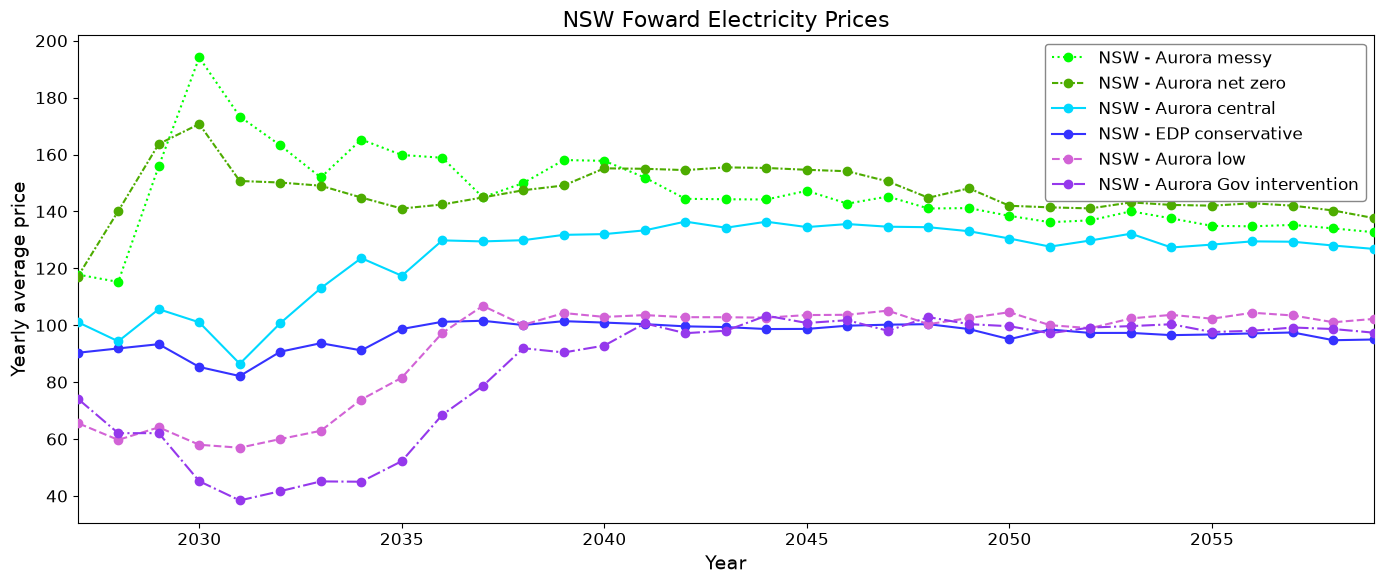

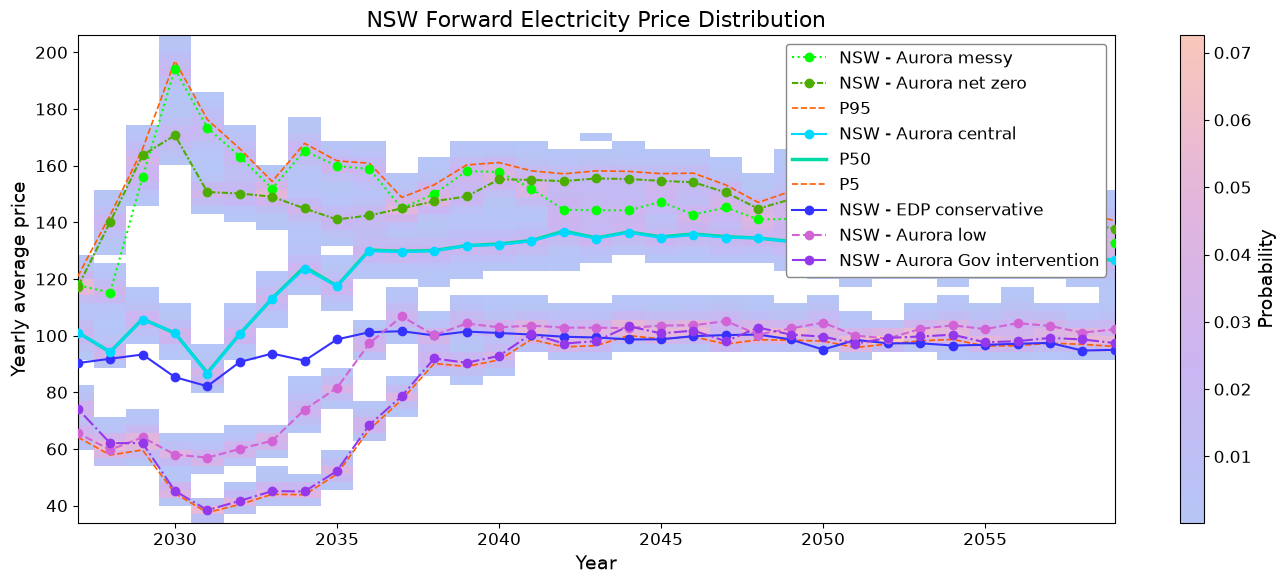

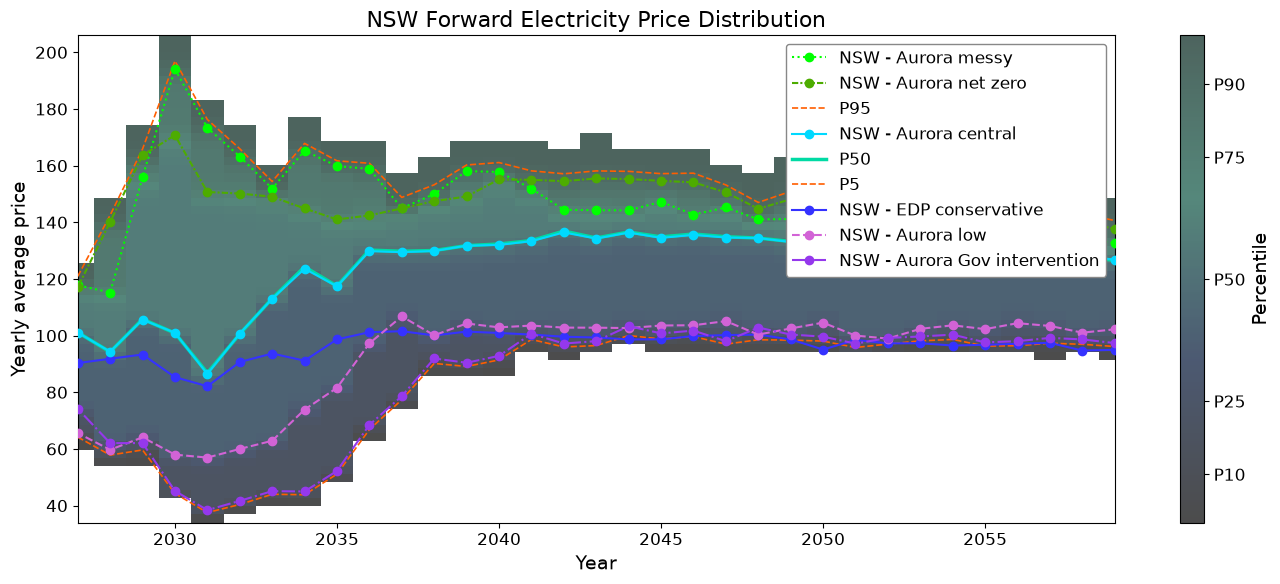

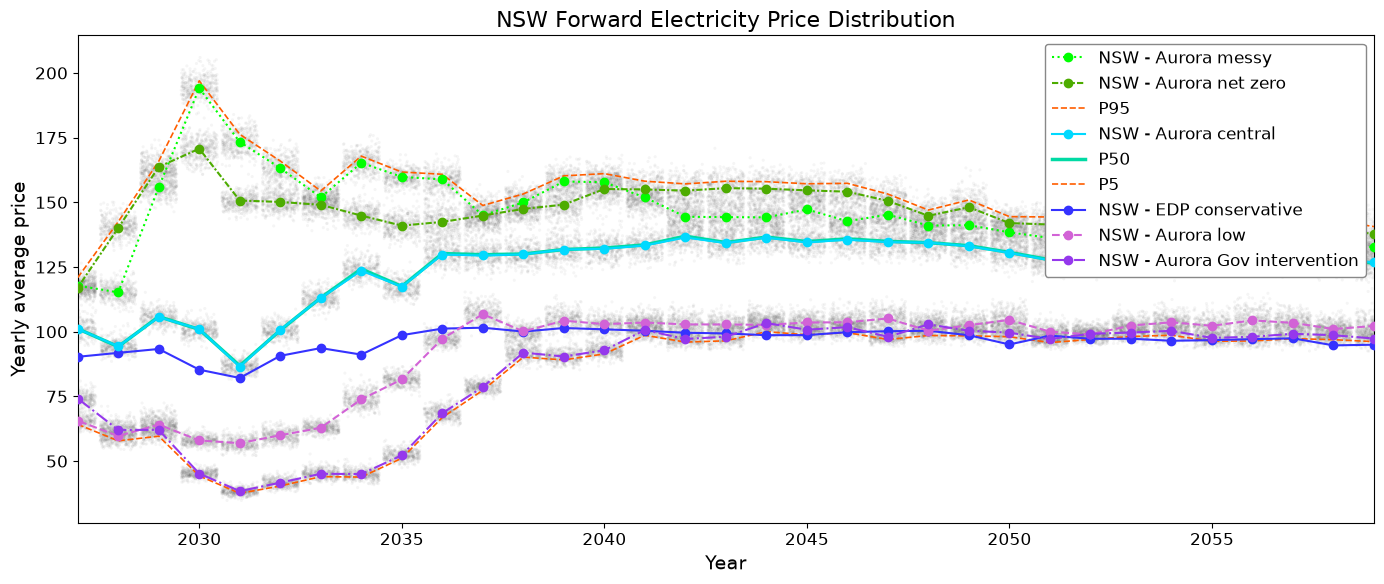

In [25]:
def plot_natural_curves(visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns):

    fig0, ax0 = plt.subplots(figsize=(14, 6))
    fig0.patch.set_facecolor("white")
    ax0.set_facecolor("white")

    # Call helper 
    draw_overlays(ax0, "NSW Foward Electricity Prices", raw_curves_agg, highlight_lines, line_colors, line_styles, columns)

    fig0.tight_layout()
    plt.show()


def plot_probability_density(visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns, base_font_size, bin_centers, density, density_colors):

    fig1, ax1 = plt.subplots(figsize=(14, 6))
    fig1.patch.set_facecolor("white")
    ax1.set_facecolor("white")

    # unique here
    density_cmap = LinearSegmentedColormap.from_list("density", density_colors)
    density_cmap.set_bad("white")
    mesh1 = ax1.pcolormesh(columns, bin_centers, density, cmap=density_cmap, shading="auto", alpha=0.35)
    cbar1 = fig1.colorbar(mesh1, ax=ax1, label="Probability")
    cbar1.ax.tick_params(labelsize=base_font_size)

    # Call helper 
    draw_overlays(ax1, visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns)

    fig1.tight_layout()
    plt.show()



def plot_cdf(visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns, base_font_size, fan_colors ,bin_centers, cdf):

    fig2, ax2 = plt.subplots(figsize=(14, 6))
    fig2.patch.set_facecolor("white")
    ax2.set_facecolor("white")

    # unique here
    fan_cmap = LinearSegmentedColormap.from_list("fan", fan_colors)
    fan_cmap.set_bad("white")
    mesh2 = ax2.pcolormesh(columns, bin_centers, cdf, cmap=fan_cmap, shading="auto", alpha=0.7)
    cbar2 = fig2.colorbar(mesh2, ax=ax2, ticks=[0.1, 0.25, 0.5, 0.75, 0.9])
    cbar2.ax.set_yticklabels(["P10", "P25", "P50", "P75", "P90"])
    cbar2.set_label("Percentile")
    cbar2.ax.tick_params(labelsize=base_font_size)

    # Call helper 
    draw_overlays(ax2, visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns)

    fig2.tight_layout()
    plt.show()


def plot_scatter(visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns, base_font_size, samples_df_agg):

    fig3, ax3 = plt.subplots(figsize=(14, 6))
    fig3.patch.set_facecolor("white")
    ax3.set_facecolor("white")
      
    # unique here
    scatter_color = "#555555"
    scatter_size = 5
    scatter_alpha = 0.06      
    scatter_jitter = 0.9 

    _jrng = np.random.default_rng(0)
    scatter_years = np.concatenate([np.full(len(samples_df_agg[y]), y, dtype=float) for y in columns])
    scatter_vals = np.concatenate([samples_df_agg[y] for y in columns])
    scatter_years = scatter_years + (_jrng.random(len(scatter_years)) - 0.5) * scatter_jitter
    ax3.scatter(scatter_years, scatter_vals, s=scatter_size, alpha=scatter_alpha,color=scatter_color, edgecolors="none", zorder=1)

    # Call helper 
    draw_overlays(ax3, visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns)

    fig3.tight_layout()
    plt.show()

plot_natural_curves(visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns)
plot_probability_density(visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns, base_font_size, bin_centers, density, density_colors)
plot_cdf(visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns, base_font_size, fan_colors ,bin_centers, cdf)
plot_scatter(visual_title, raw_curves_agg, highlight_lines, line_colors, line_styles, columns, base_font_size, samples_df_agg)


# Table calculations

In [28]:
def total_metrics():
    totals_df = []
    for year in columns:
        target = raw_curves_agg.loc[year, "NSW - EDP conservative"]

        distribution = samples_df_agg[year]

        # Calculate target percentile
        number_of_values_below_x = (distribution <= target).sum()
        total_number_of_values_n = distribution.count()
        target_percentile = (number_of_values_below_x/total_number_of_values_n)*100

        # Calculate target z-score
        target_z_score = (target - distribution.mean()) / distribution.std()
            
        totals_df.append({
            "Year": year,
            "EDP_conservative": round(target, 2),
            "number_of_values_below_x": round(number_of_values_below_x, 1),
            "Percentile": round(target_percentile, 1),
     
            "distribution.min()": round(distribution.min(), 2),
            "distribution.mean()": round(distribution.mean(), 2),
            "distribution.max()": round(distribution.max(), 2),
            "Z_score": round(target_z_score, 2),
        })


    totals_df = pd.DataFrame(totals_df)

    return totals_df


totals_df = total_metrics()

avg_value = totals_df["EDP_conservative"].mean()
avg_percentile = totals_df["Percentile"].mean()
avg_z = totals_df["Z_score"].mean()

totals_df.loc[len(totals_df)] = {
    "Year": "All years",
    "EDP_conservative": round(avg_value, 2),
    "Percentile": round(avg_percentile, 1),
    "Z_score": round(avg_z, 2),
}

totals_df

,Year,EDP_conservative,number_of_values_below_x,Percentile,distribution.min(),distribution.mean(),distribution.max(),Z_score
0,2027,90.31,789.0,39.4,60.810001,95.529999,126.849998,-0.24
1,2028,91.84,844.0,42.2,54.360001,94.860001,150.089996,-0.10
2,2029,93.34,789.0,39.4,55.360001,110.989998,174.149994,-0.40
3,2030,85.34,789.0,39.4,41.610001,114.820000,205.979996,-0.49
4,2031,82.14,792.0,39.6,34.799999,102.129997,183.949997,-0.38
5,2032,90.69,789.0,39.4,37.830002,103.889999,174.169998,-0.27
6,2033,93.68,789.0,39.4,40.980000,105.050003,159.630005,-0.26
7,2034,91.16,789.0,39.4,39.779999,111.250000,176.119995,-0.45
8,2035,98.67,789.0,39.4,47.430000,110.970001,168.419998,-0.31
9,2036,101.21,775.0,38.8,63.509998,119.730003,168.720001,-0.57
